In [2]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

plt.style.use("default")

In [3]:
stocks = [
    "RELIANCE.NS",
    "HDFCBANK.NS",
    "INFY.NS",
    "SUNPHARMA.NS",
    "LT.NS",
    "ITC.NS",
    "BHARTIARTL.NS",
    "BAJFINANCE.NS"
]

In [4]:
prices = yf.download(
    stocks,
    start="2018-01-01",
    end="2025-01-01",
    auto_adjust=True,
    progress=False
)["Close"]

prices.head()

Ticker,BAJFINANCE.NS,BHARTIARTL.NS,HDFCBANK.NS,INFY.NS,ITC.NS,LT.NS,RELIANCE.NS,SUNPHARMA.NS
Date,,,,,,,,
2018-01-01,168.066788,453.573059,432.689026,406.448944,178.774948,1107.630859,400.015350,531.673218
2018-01-02,167.969376,443.821075,436.853760,404.934845,177.718536,1098.010376,400.630829,529.913452
2018-01-03,167.058746,445.238861,432.257355,401.631561,177.991150,1120.458252,402.235779,527.042297
2018-01-04,170.827881,449.363007,433.948944,399.311340,178.263779,1155.953125,404.654114,538.295471
2018-01-05,176.720154,463.969452,434.812195,397.974274,179.183899,1155.250122,405.951202,536.026367


In [5]:
prices.to_csv("data/prices.csv")

In [6]:
returns = prices.pct_change().dropna()

returns.head()

Ticker,BAJFINANCE.NS,BHARTIARTL.NS,HDFCBANK.NS,INFY.NS,ITC.NS,LT.NS,RELIANCE.NS,SUNPHARMA.NS
Date,,,,,,,,
2018-01-02,-0.000580,-0.021500,0.009625,-0.003725,-0.005909,-0.008686,0.001539,-0.003310
2018-01-03,-0.005421,0.003194,-0.010522,-0.008158,0.001534,0.020444,0.004006,-0.005418
2018-01-04,0.022562,0.009263,0.003913,-0.005777,0.001532,0.031679,0.006012,0.021352
2018-01-05,0.034492,0.032505,0.001989,-0.003348,0.005162,-0.000608,0.003205,-0.004215
2018-01-08,0.012317,-0.043796,-0.001610,0.023765,0.010270,0.017758,0.005741,0.022203


In [7]:
returns.to_csv("data/returns.csv")

In [17]:
weights = np.array([
    0.15,
    0.15,
    0.15,
    0.15,
    0.15,
    0.15,
    0.15,
    0.15 ])
weights.sum()

np.float64(1.2)

In [19]:
portfolio_returns = returns.dot(weights)

portfolio_returns.head()

Date
2018-01-02   -0.004882
2018-01-03   -0.000051
2018-01-04    0.013580
2018-01-05    0.010377
2018-01-08    0.006997
dtype: float64

In [ ]:
portfolio_nav = (
    1 + portfolio_returns
).cumprod() * 100000

In [21]:
portfolio_nav.head()

Date
2018-01-02     99511.810701
2018-01-03     99506.734383
2018-01-04    100858.064828
2018-01-05    101904.692808
2018-01-08    102617.738855
dtype: float64

In [22]:
portfolio_nav.to_csv(
    "outputs/portfolio_nav.csv"
)

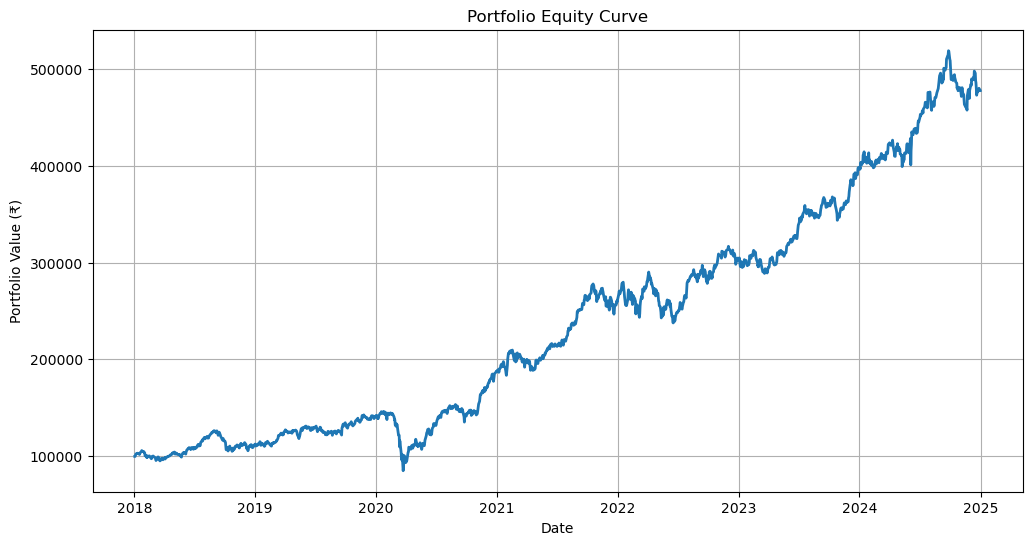

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(
    portfolio_nav,
    linewidth=2
)

plt.title(
    "Portfolio Equity Curve"
)

plt.xlabel("Date")
plt.ylabel("Portfolio Value (₹)")

plt.grid(True)

plt.show()

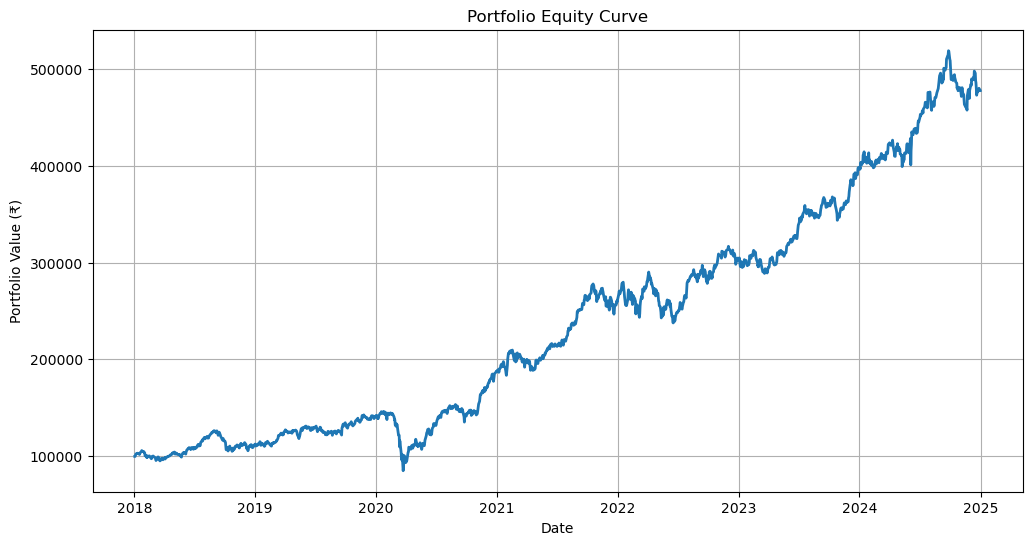

In [24]:
plt.figure(figsize=(12,6))

plt.plot(
    portfolio_nav,
    linewidth=2
)

plt.title(
    "Portfolio Equity Curve"
)

plt.xlabel("Date")
plt.ylabel("Portfolio Value (₹)")

plt.grid(True)

plt.savefig(
    "figures/equity_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [25]:
years = len(portfolio_returns) / 252

cagr = (
    portfolio_nav.iloc[-1]
    /
    portfolio_nav.iloc[0]
) ** (1 / years) - 1

print(
    f"CAGR: {cagr:.2%}"
)

CAGR: 25.75%


In [26]:
volatility = (
    portfolio_returns.std()
    *
    np.sqrt(252)
)

print(
    f"Volatility: {volatility:.2%}"
)

Volatility: 21.53%


In [34]:
risk_free = 0.06

sharpe = (
    (portfolio_returns.mean() * 252)
    - risk_free
) / volatility

print(sharpe)

0.891621795929153


In [35]:
metrics = pd.DataFrame({
    "Metric": [
        "CAGR",
        "Volatility",
        "Sharpe Ratio"
    ],
    "Value": [
        round(cagr * 100, 2),
        round(volatility * 100, 2),
        round(sharpe, 2)
    ]
})

metrics

,Metric,Value
0,CAGR,25.75
1,Volatility,21.53
2,Sharpe Ratio,0.89


In [36]:
metrics.to_csv(
    "outputs/performance_metrics.csv",
    index=False
)

In [37]:
running_max = portfolio_nav.cummax()

drawdown = (
    portfolio_nav
    -
    running_max
) / running_max

In [38]:
max_drawdown = drawdown.min()

print(
    f"Maximum Drawdown: {max_drawdown:.2%}"
)

Maximum Drawdown: -42.01%


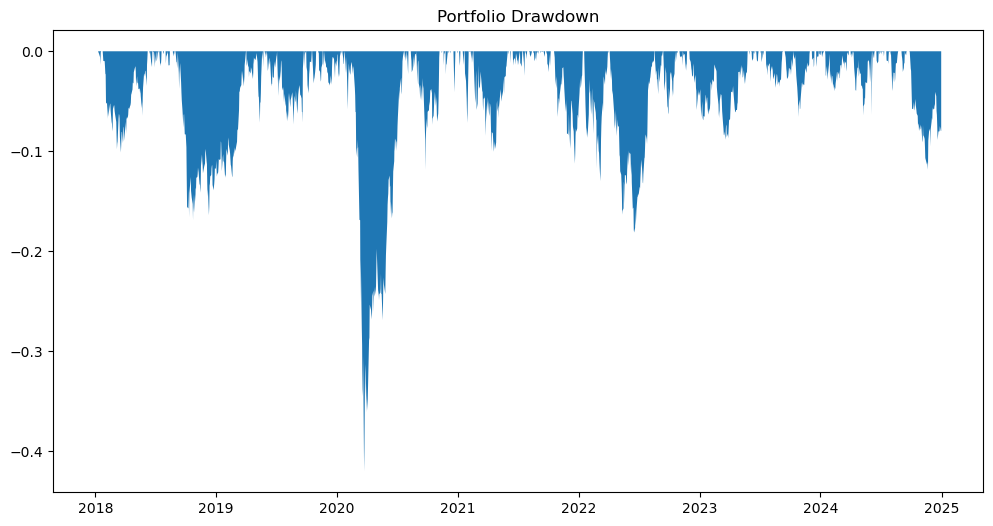

In [39]:
plt.figure(figsize=(12,6))

plt.fill_between(
    drawdown.index,
    drawdown,
    0
)

plt.title(
    "Portfolio Drawdown"
)

plt.savefig(
    "figures/drawdown.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [40]:
print(portfolio_nav.iloc[0])
print(portfolio_nav.iloc[-1])

99511.81070051179
477943.63334000093


In [41]:
running_max = portfolio_nav.cummax()

drawdown = (
    portfolio_nav - running_max
) / running_max

In [42]:
max_drawdown = drawdown.min()

print(
    f"Maximum Drawdown: {max_drawdown:.2%}"
)

Maximum Drawdown: -42.01%


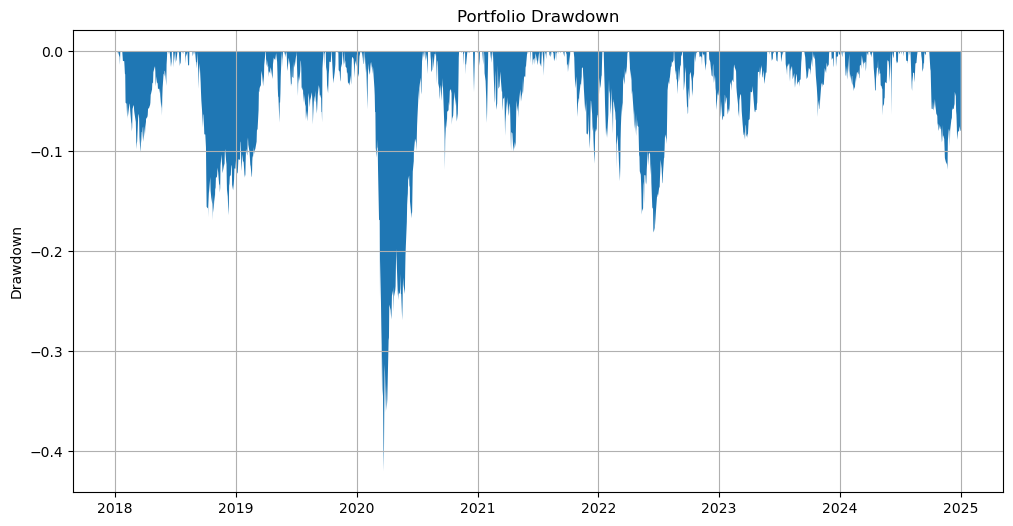

In [51]:
plt.figure(figsize=(12,6))

plt.fill_between(
    drawdown.index,
    drawdown,
    0
)

plt.title(
    "Portfolio Drawdown"
)

plt.ylabel("Drawdown")

plt.grid(True)

plt.show()

In [52]:
plt.savefig(
    "figures/drawdown.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [53]:
downside_returns = portfolio_returns[
    portfolio_returns < 0
]

downside_vol = (
    downside_returns.std()
    * np.sqrt(252)
)

sortino = (
    (portfolio_returns.mean() * 252)
    - risk_free
) / downside_vol

print(
    f"Sortino Ratio: {sortino:.2f}"
)

Sortino Ratio: 1.08


In [54]:
calmar = (
    cagr
    /
    abs(max_drawdown)
)

print(
    f"Calmar Ratio: {calmar:.2f}"
)

Calmar Ratio: 0.61


In [55]:
metrics = pd.DataFrame({

    "Metric":[
        "CAGR",
        "Volatility",
        "Sharpe Ratio",
        "Sortino Ratio",
        "Max Drawdown",
        "Calmar Ratio"
    ],

    "Value":[
        round(cagr*100,2),
        round(volatility*100,2),
        round(sharpe,2),
        round(sortino,2),
        round(max_drawdown*100,2),
        round(calmar,2)
    ]
})

metrics

,Metric,Value
0,CAGR,25.75
1,Volatility,21.53
2,Sharpe Ratio,0.89
3,Sortino Ratio,1.08
4,Max Drawdown,-42.01
5,Calmar Ratio,0.61


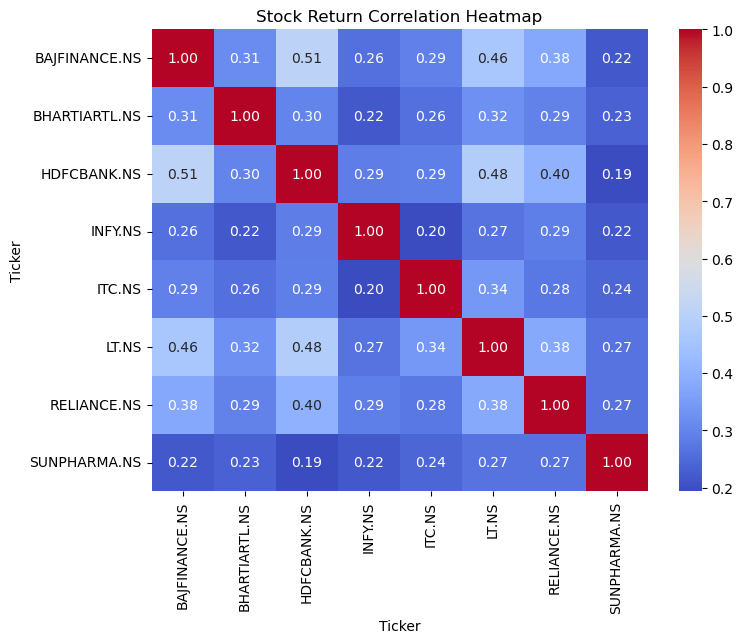

In [48]:
import seaborn as sns

corr_matrix = returns.corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title(
    "Stock Return Correlation Heatmap"
)

plt.show()

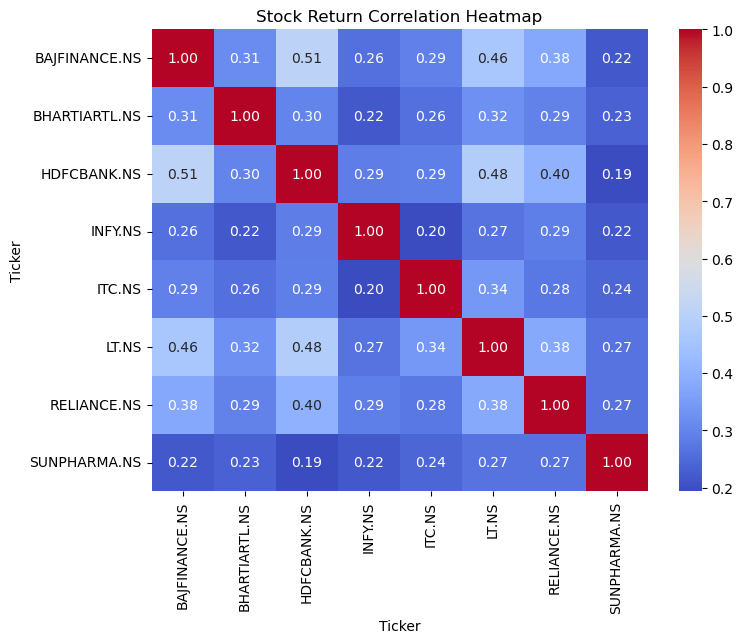

In [50]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title(
    "Stock Return Correlation Heatmap"
)

plt.savefig(
    "figures/correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [56]:
rolling_vol = (
    portfolio_returns
    .rolling(30)
    .std()
    * np.sqrt(252)
)

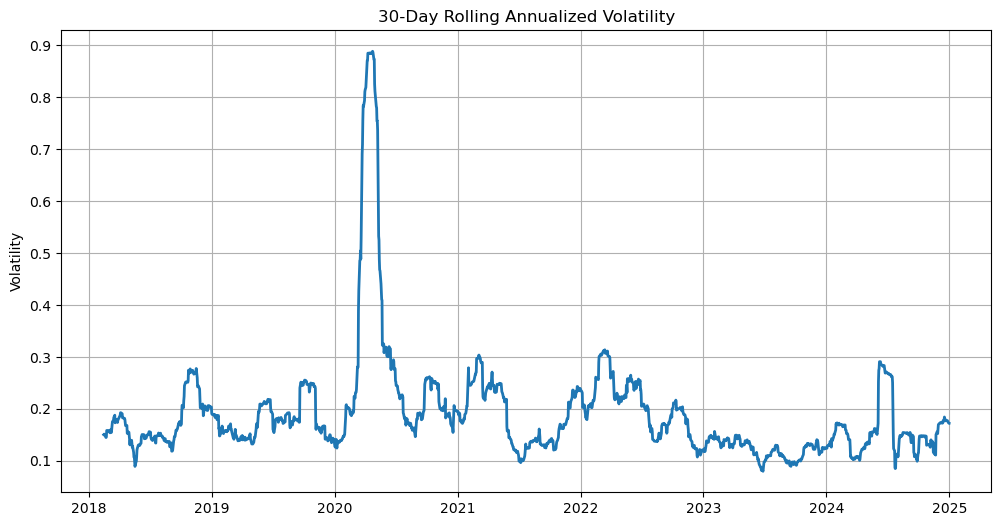

In [57]:
plt.figure(figsize=(12,6))

plt.plot(
    rolling_vol,
    linewidth=2
)

plt.title(
    "30-Day Rolling Annualized Volatility"
)

plt.ylabel(
    "Volatility"
)

plt.grid(True)

plt.show()

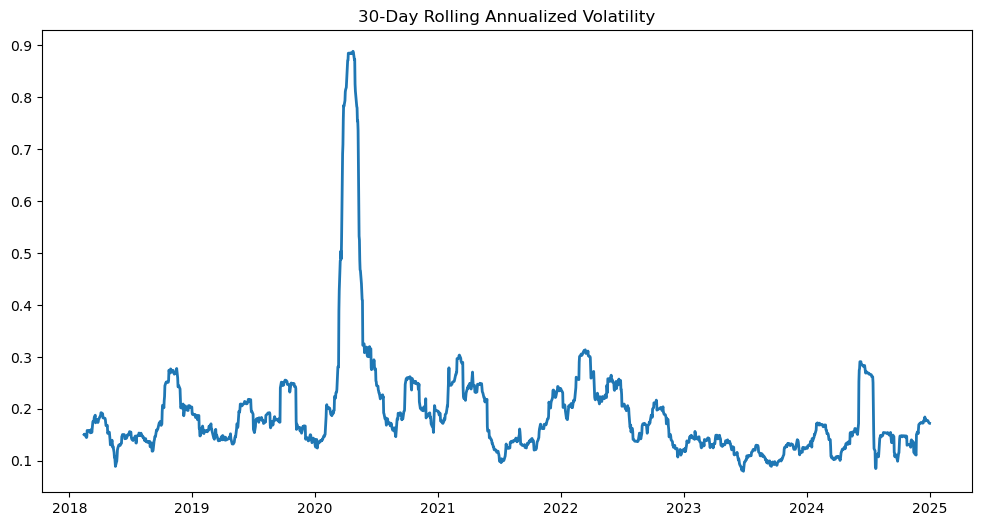

In [58]:
plt.figure(figsize=(12,6))

plt.plot(
    rolling_vol,
    linewidth=2
)

plt.title(
    "30-Day Rolling Annualized Volatility"
)

plt.savefig(
    "figures/rolling_volatility.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

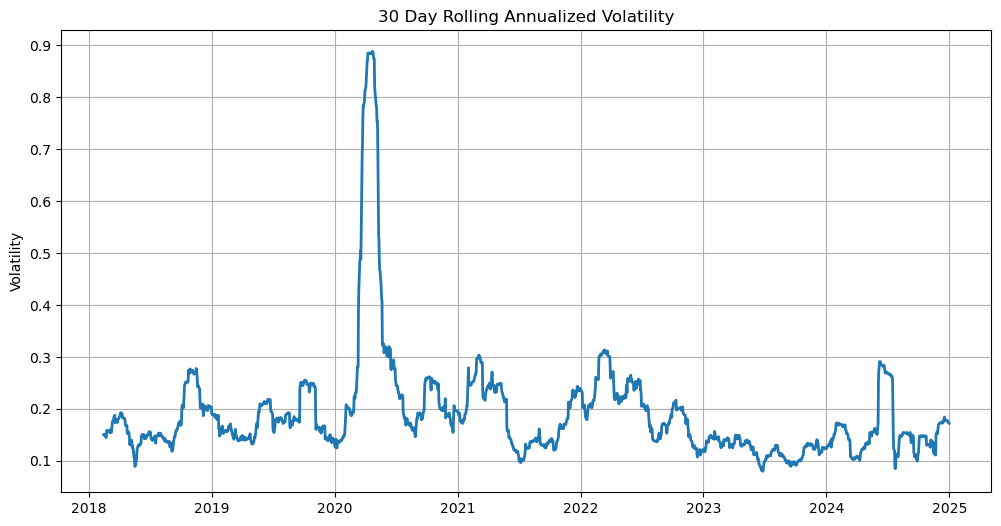

In [60]:
rolling_vol = (
    portfolio_returns
    .rolling(window=30)
    .std()
    * np.sqrt(252)
)

plt.figure(figsize=(12,6))

plt.plot(
    rolling_vol,
    linewidth=2
)

plt.title(
    "30 Day Rolling Annualized Volatility"
)

plt.ylabel("Volatility")

plt.grid(True)

plt.savefig(
    "figures/rolling_volatility.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

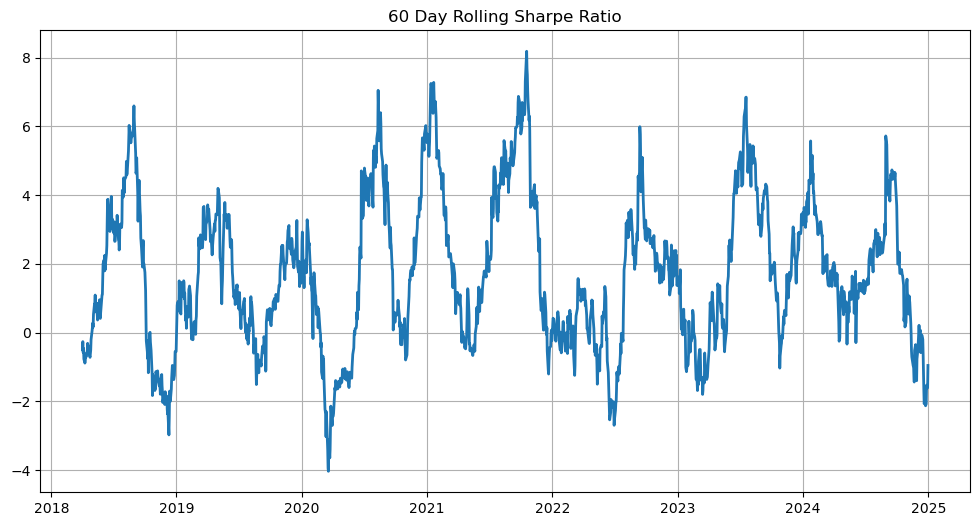

In [61]:
rolling_mean = (
    portfolio_returns
    .rolling(60)
    .mean()
)

rolling_std = (
    portfolio_returns
    .rolling(60)
    .std()
)

rolling_sharpe = (
    rolling_mean * 252
) / (
    rolling_std * np.sqrt(252)
)

plt.figure(figsize=(12,6))

plt.plot(
    rolling_sharpe,
    linewidth=2
)

plt.title(
    "60 Day Rolling Sharpe Ratio"
)

plt.grid(True)

plt.savefig(
    "figures/rolling_sharpe.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [62]:
confidence_level = 0.95

var_95 = np.percentile(
    portfolio_returns,
    5
)

print(
    f"95% Historical VaR: {var_95:.2%}"
)

95% Historical VaR: -1.79%


In [63]:
var_99 = np.percentile(
    portfolio_returns,
    1
)

print(
    f"99% Historical VaR: {var_99:.2%}"
)

99% Historical VaR: -3.62%


In [64]:
cvar_95 = portfolio_returns[
    portfolio_returns <= var_95
].mean()

print(
    f"95% CVaR: {cvar_95:.2%}"
)

95% CVaR: -3.11%


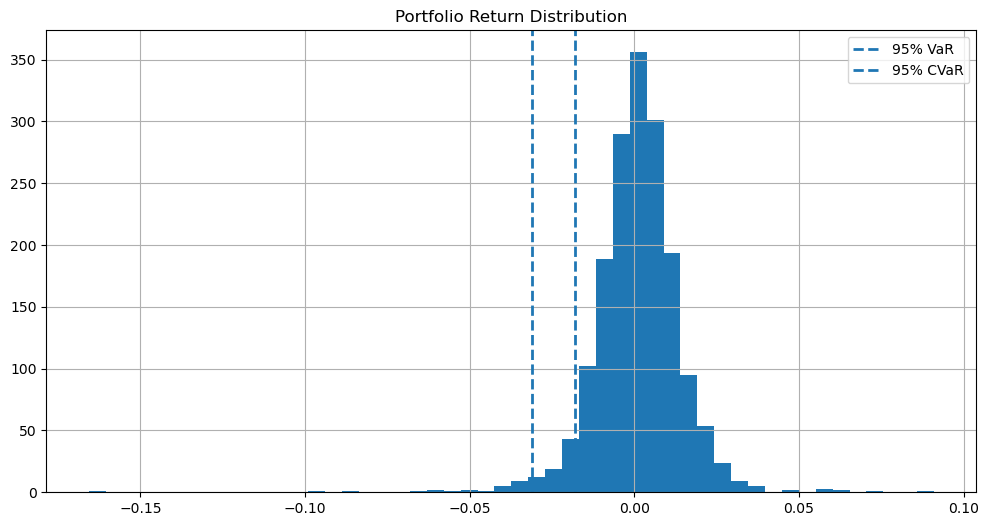

In [65]:
plt.figure(figsize=(12,6))

plt.hist(
    portfolio_returns,
    bins=50
)

plt.axvline(
    var_95,
    linestyle="--",
    linewidth=2,
    label="95% VaR"
)

plt.axvline(
    cvar_95,
    linestyle="--",
    linewidth=2,
    label="95% CVaR"
)

plt.title(
    "Portfolio Return Distribution"
)

plt.legend()

plt.grid(True)

plt.savefig(
    "figures/return_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [66]:
metrics = pd.DataFrame({

    "Metric":[
        "CAGR",
        "Volatility",
        "Sharpe Ratio",
        "Sortino Ratio",
        "Max Drawdown",
        "Calmar Ratio",
        "95% VaR",
        "95% CVaR"
    ],

    "Value":[
        round(cagr*100,2),
        round(volatility*100,2),
        round(sharpe,2),
        round(sortino,2),
        round(max_drawdown*100,2),
        round(calmar,2),
        round(var_95*100,2),
        round(cvar_95*100,2)
    ]
})

metrics

,Metric,Value
0,CAGR,25.75
1,Volatility,21.53
2,Sharpe Ratio,0.89
3,Sortino Ratio,1.08
4,Max Drawdown,-42.01
5,Calmar Ratio,0.61
6,95% VaR,-1.79
7,95% CVaR,-3.11


In [67]:
pip install arch

Note: you may need to restart the kernel to use updated packages.


In [68]:
from arch import arch_model

In [69]:
garch_returns = portfolio_returns * 100

In [70]:
from arch import arch_model

garch = arch_model(
    garch_returns,
    vol='Garch',
    p=1,
    q=1,
    mean='Zero'
)

garch_fit = garch.fit(
    disp='off'
)

print(
    garch_fit.summary()
)

                       Zero Mean - GARCH Model Results                        
Dep. Variable:                   None   R-squared:                       0.000
Mean Model:                 Zero Mean   Adj. R-squared:                  0.001
Vol Model:                      GARCH   Log-Likelihood:               -2704.55
Distribution:                  Normal   AIC:                           5415.10
Method:            Maximum Likelihood   BIC:                           5431.46
                                        No. Observations:                 1726
Date:                Wed, Jun 10 2026   Df Residuals:                     1726
Time:                        15:10:25   Df Model:                            0
                             Volatility Model                             
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
omega          0.0715  3.398e-02      2.105  3.533e-02 [4.914e-0

In [71]:
garch_vol = (
    garch_fit.conditional_volatility
    /
    100
)

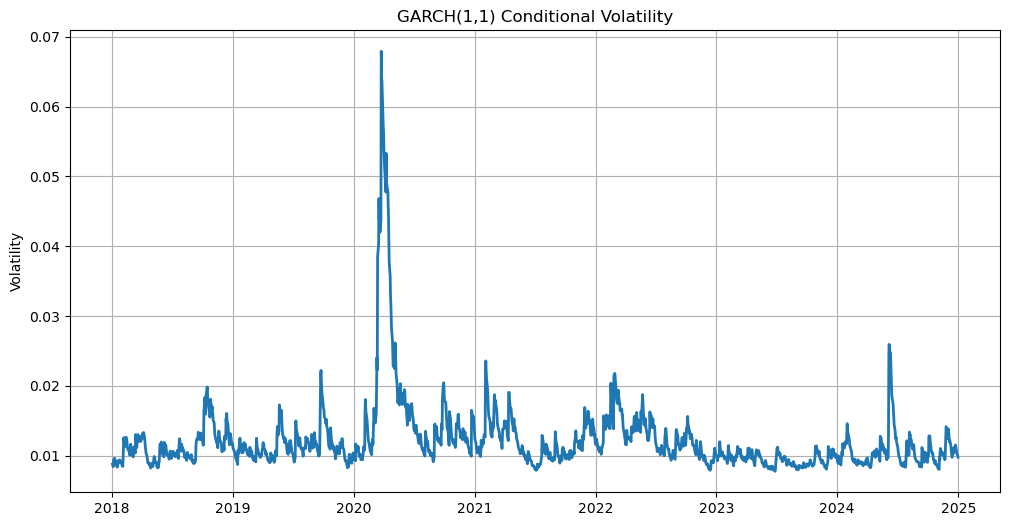

In [72]:
plt.figure(figsize=(12,6))

plt.plot(
    garch_vol,
    linewidth=2
)

plt.title(
    "GARCH(1,1) Conditional Volatility"
)

plt.ylabel(
    "Volatility"
)

plt.grid(True)

plt.show()

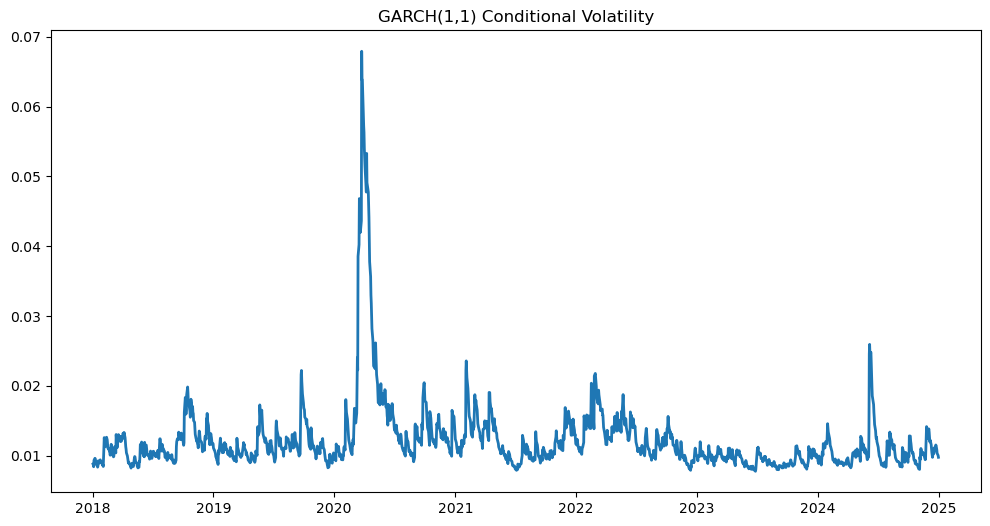

In [73]:
plt.figure(figsize=(12,6))

plt.plot(
    garch_vol,
    linewidth=2
)

plt.title(
    "GARCH(1,1) Conditional Volatility"
)

plt.savefig(
    "figures/garch_volatility.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

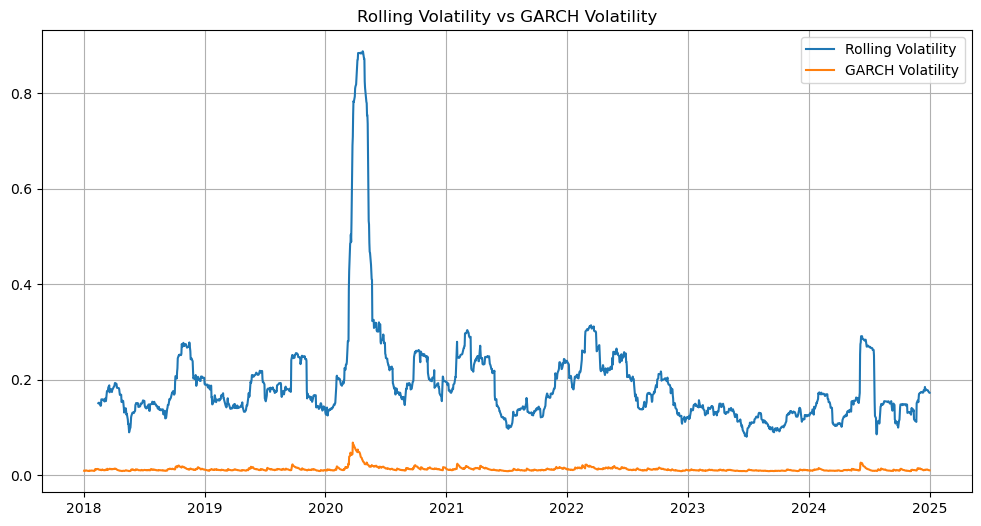

In [74]:
plt.figure(figsize=(12,6))

plt.plot(
    rolling_vol,
    label="Rolling Volatility"
)

plt.plot(
    garch_vol,
    label="GARCH Volatility"
)

plt.title(
    "Rolling Volatility vs GARCH Volatility"
)

plt.legend()

plt.grid(True)

plt.show()

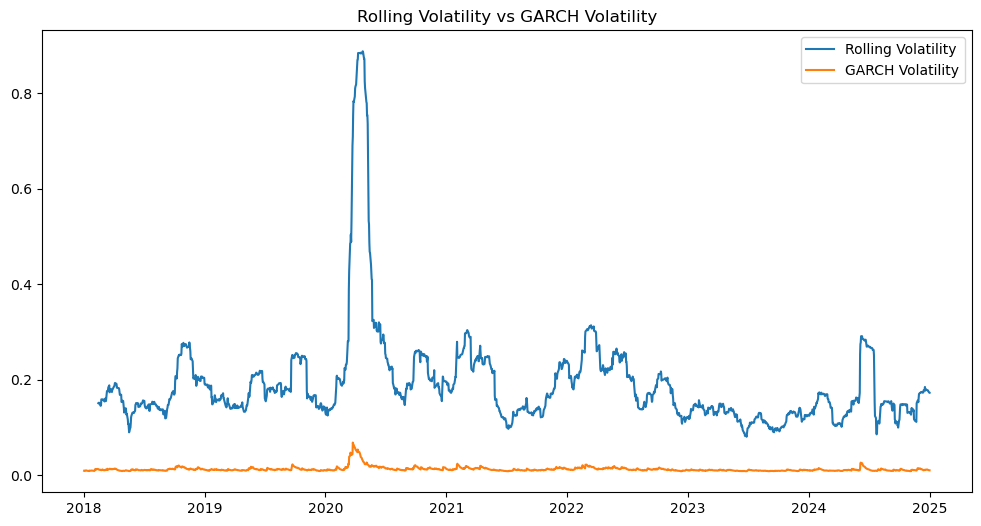

In [75]:
plt.figure(figsize=(12,6))

plt.plot(
    rolling_vol,
    label="Rolling Volatility"
)

plt.plot(
    garch_vol,
    label="GARCH Volatility"
)

plt.title(
    "Rolling Volatility vs GARCH Volatility"
)

plt.legend()

plt.savefig(
    "figures/rolling_vs_garch.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [76]:
forecast = garch_fit.forecast(
    horizon=30
)

In [77]:
future_vol = np.sqrt(
    forecast.variance.iloc[-1]
)

future_vol

h.01    0.937120
h.02    0.954071
h.03    0.969985
h.04    0.984943
h.05    0.999021
h.06    1.012283
h.07    1.024790
h.08    1.036594
h.09    1.047743
h.10    1.058282
h.11    1.068250
h.12    1.077684
h.13    1.086619
h.14    1.095083
h.15    1.103107
h.16    1.110717
h.17    1.117936
h.18    1.124787
h.19    1.131292
h.20    1.137470
h.21    1.143340
h.22    1.148917
h.23    1.154219
h.24    1.159261
h.25    1.164055
h.26    1.168616
h.27    1.172955
h.28    1.177084
h.29    1.181014
h.30    1.184756
Name: 2024-12-31 00:00:00, dtype: float64

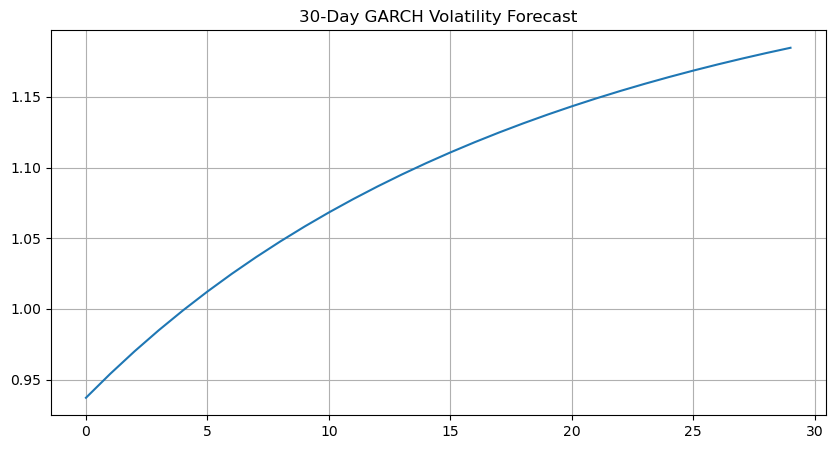

In [78]:
plt.figure(figsize=(10,5))

plt.plot(
    future_vol.values
)

plt.title(
    "30-Day GARCH Volatility Forecast"
)

plt.grid(True)

plt.show()

In [79]:
from hmmlearn.hmm import GaussianHMM

In [80]:
hmm_returns = (
    portfolio_returns
    .values
    .reshape(-1,1)
)

In [81]:
hmm = GaussianHMM(
    n_components=3,
    covariance_type="full",
    n_iter=1000,
    random_state=42
)

hmm.fit(hmm_returns)

Model is not converging.  Current: 5233.744026981752 is not greater than 5233.944256232654. Delta is -0.20022925090233912


,n_components,3
,covariance_type,'full'
,min_covar,0.001
,startprob_prior,1.0
,transmat_prior,1.0
,means_prior,0
,means_weight,0
,covars_prior,0.01
,covars_weight,1
,algorithm,'viterbi'
,random_state,42


In [82]:
hidden_states = hmm.predict(
    hmm_returns
)

In [83]:
regime_df = pd.DataFrame({
    "Return": portfolio_returns.values,
    "Regime": hidden_states
},
index=portfolio_returns.index)

regime_df.head()

,Return,Regime
Date,,
2018-01-02,-0.004882,0
2018-01-03,-0.000051,1
2018-01-04,0.013580,0
2018-01-05,0.010377,1
2018-01-08,0.006997,0


In [84]:
regime_stats = regime_df.groupby(
    "Regime"
)["Return"].agg([
    "mean",
    "std",
    "count"
])

print(regime_stats)

            mean       std  count
Regime                           
0       0.000802  0.011087    836
1       0.001384  0.010373    841
2      -0.002207  0.050748     49


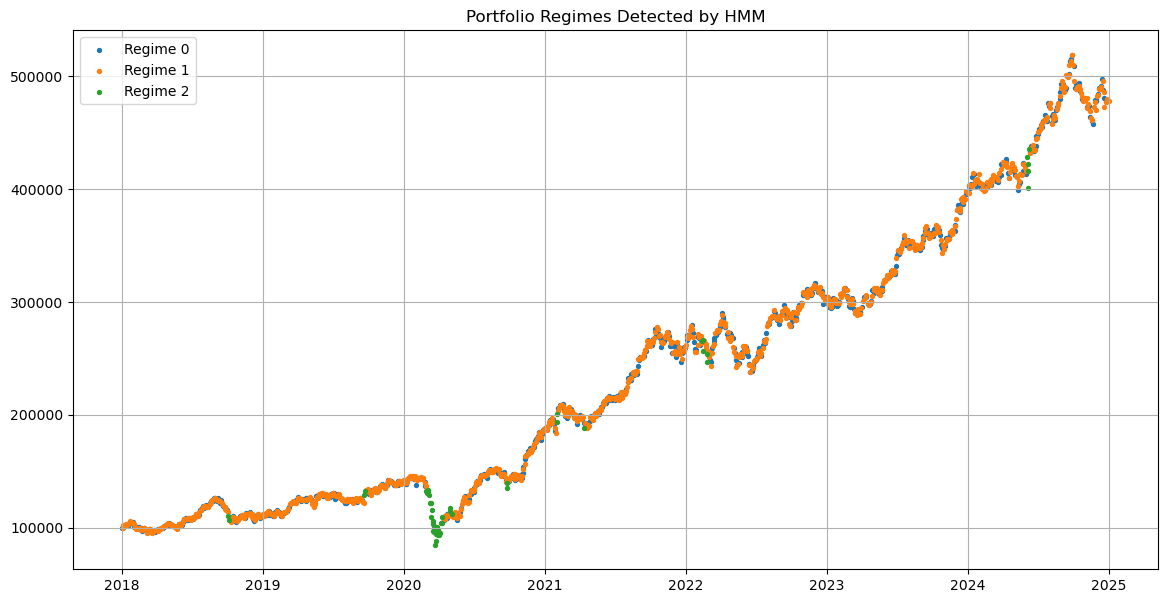

In [85]:
plt.figure(figsize=(14,7))

for regime in range(3):

    subset = regime_df[
        regime_df["Regime"] == regime
    ]

    plt.scatter(
        subset.index,
        portfolio_nav.loc[subset.index],
        s=8,
        label=f"Regime {regime}"
    )

plt.title(
    "Portfolio Regimes Detected by HMM"
)

plt.legend()

plt.grid(True)

plt.show()

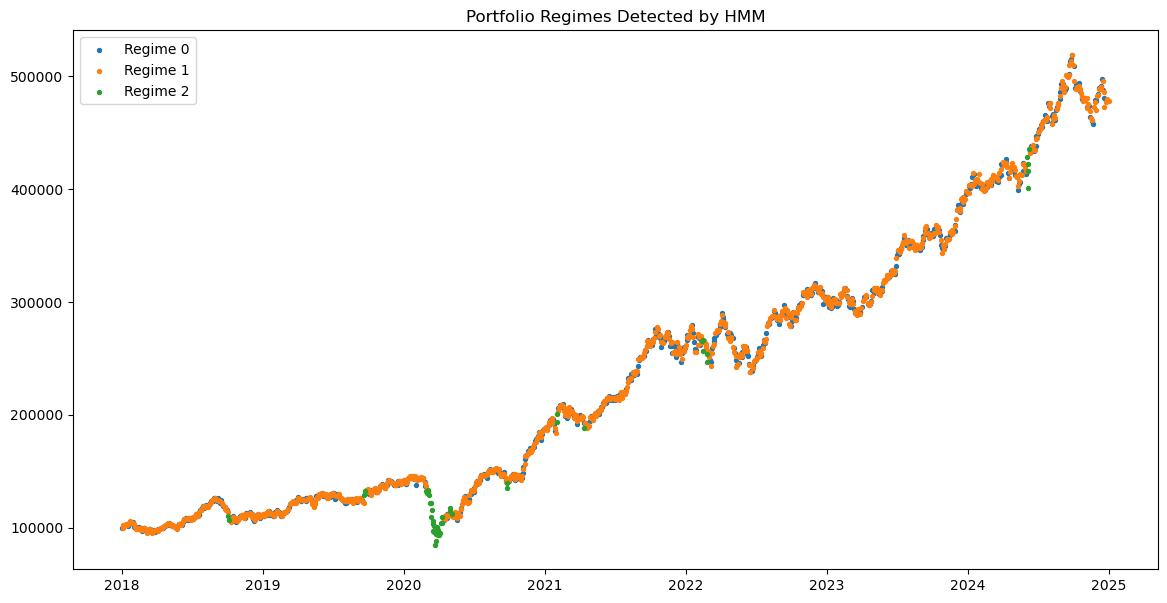

In [86]:
plt.figure(figsize=(14,7))

for regime in range(3):

    subset = regime_df[
        regime_df["Regime"] == regime
    ]

    plt.scatter(
        subset.index,
        portfolio_nav.loc[subset.index],
        s=8,
        label=f"Regime {regime}"
    )

plt.title(
    "Portfolio Regimes Detected by HMM"
)

plt.legend()

plt.savefig(
    "figures/hmm_regimes.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [87]:
regime_df["Regime"].value_counts()

Regime
1    841
0    836
2     49
Name: count, dtype: int64

In [88]:
print(
    hmm.transmat_
)

[[9.69854751e-04 9.99004272e-01 2.58730193e-05]
 [9.68004922e-01 1.06656565e-02 2.13294214e-02]
 [1.67851504e-01 8.10755023e-02 7.51072994e-01]]


In [89]:
regime_stats = regime_df.groupby(
    "Regime"
)["Return"].agg([
    "mean",
    "std",
    "count"
])

regime_stats

,mean,std,count
Regime,,,
0,0.000802,0.011087,836
1,0.001384,0.010373,841
2,-0.002207,0.050748,49


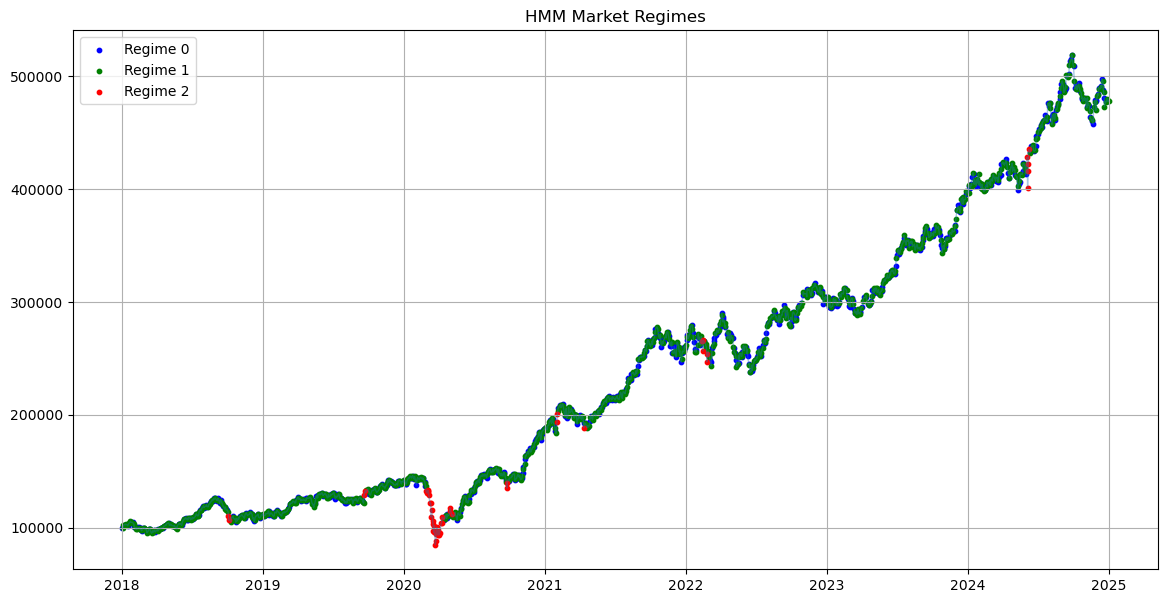

In [90]:
plt.figure(figsize=(14,7))

colors = {
    0:"blue",
    1:"green",
    2:"red"
}

for regime in range(3):

    subset = regime_df[
        regime_df["Regime"] == regime
    ]

    plt.scatter(
        subset.index,
        portfolio_nav.loc[subset.index],
        c=colors[regime],
        s=10,
        label=f"Regime {regime}"
    )

plt.plot(
    portfolio_nav,
    alpha=0.4,
    linewidth=1
)

plt.title(
    "HMM Market Regimes"
)

plt.legend()

plt.grid(True)

plt.show()

In [91]:
from scipy.optimize import minimize

In [92]:
cov_matrix = returns.cov() * 252

In [93]:
def portfolio_volatility(weights):

    return np.sqrt(
        np.dot(
            weights.T,
            np.dot(
                cov_matrix,
                weights
            )
        )
    )

In [94]:
num_assets = len(stocks)

constraints = ({
    'type':'eq',
    'fun':lambda x: np.sum(x)-1
})

bounds = tuple(
    (0,1)
    for asset in range(num_assets)
)

In [95]:
initial_weights = np.repeat(
    1/num_assets,
    num_assets
)

In [96]:
optimal = minimize(
    portfolio_volatility,
    initial_weights,
    method='SLSQP',
    bounds=bounds,
    constraints=constraints
)

In [97]:
min_var_weights = optimal.x

pd.DataFrame({

    "Stock":stocks,
    "Weight":min_var_weights

})

,Stock,Weight
0,RELIANCE.NS,2.534323e-18
1,HDFCBANK.NS,9.423993e-02
2,INFY.NS,1.828117e-01
3,SUNPHARMA.NS,1.836760e-01
4,LT.NS,2.479824e-01
5,ITC.NS,5.727679e-02
6,BHARTIARTL.NS,6.503186e-02
7,BAJFINANCE.NS,1.689814e-01


In [98]:
min_var_returns = returns.dot(
    min_var_weights
)

In [99]:
min_var_nav = (
    1 + min_var_returns
).cumprod()*100000

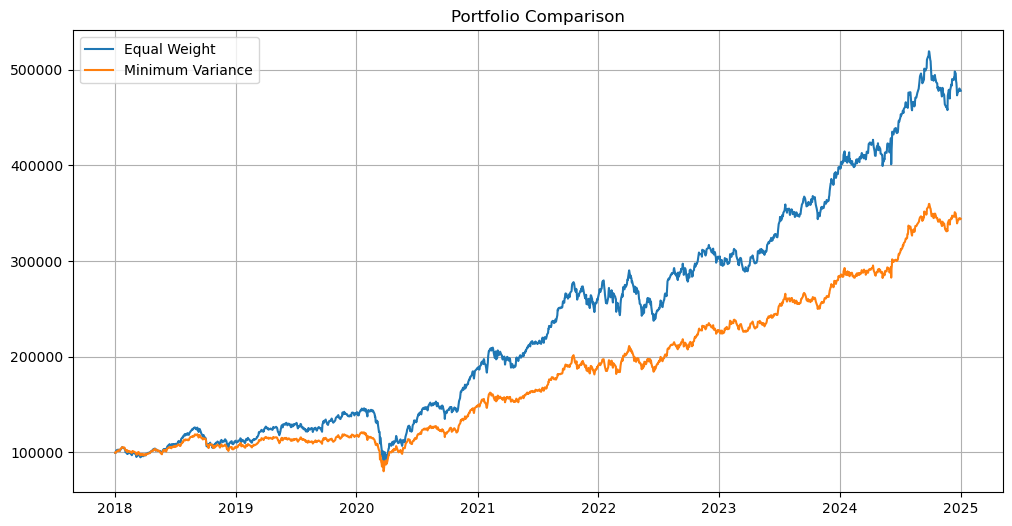

In [100]:
plt.figure(figsize=(12,6))

plt.plot(
    portfolio_nav,
    label="Equal Weight"
)

plt.plot(
    min_var_nav,
    label="Minimum Variance"
)

plt.title(
    "Portfolio Comparison"
)

plt.legend()

plt.grid(True)

plt.show()

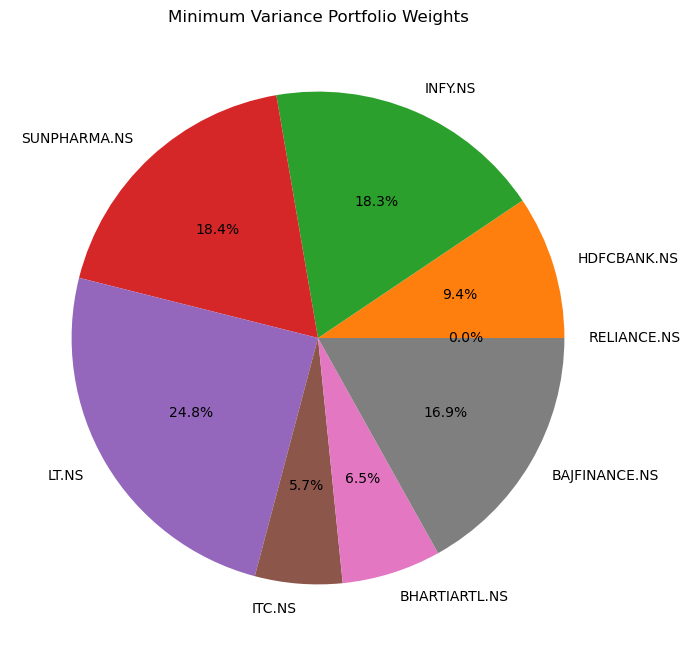

In [101]:
plt.figure(figsize=(8,8))

plt.pie(
    min_var_weights,
    labels=stocks,
    autopct='%1.1f%%'
)

plt.title(
    "Minimum Variance Portfolio Weights"
)

plt.show()

In [102]:
asset_vols = returns.std() * np.sqrt(252)

asset_vols

Ticker
BAJFINANCE.NS    0.370386
BHARTIARTL.NS    0.305286
HDFCBANK.NS      0.250264
INFY.NS          0.273492
ITC.NS           0.245036
LT.NS            0.274313
RELIANCE.NS      0.289286
SUNPHARMA.NS     0.282181
dtype: float64

In [103]:
inv_vol = 1 / asset_vols

risk_parity_weights = (
    inv_vol
    /
    inv_vol.sum()
)

risk_parity_weights

Ticker
BAJFINANCE.NS    0.095218
BHARTIARTL.NS    0.115522
HDFCBANK.NS      0.140921
INFY.NS          0.128952
ITC.NS           0.143927
LT.NS            0.128566
RELIANCE.NS      0.121912
SUNPHARMA.NS     0.124981
dtype: float64

In [104]:
rp_weights_df = pd.DataFrame({

    "Stock": stocks,
    "Weight": risk_parity_weights

})

rp_weights_df

,Stock,Weight
Ticker,,
BAJFINANCE.NS,RELIANCE.NS,0.095218
BHARTIARTL.NS,HDFCBANK.NS,0.115522
HDFCBANK.NS,INFY.NS,0.140921
INFY.NS,SUNPHARMA.NS,0.128952
ITC.NS,LT.NS,0.143927
LT.NS,ITC.NS,0.128566
RELIANCE.NS,BHARTIARTL.NS,0.121912
SUNPHARMA.NS,BAJFINANCE.NS,0.124981


In [105]:
risk_parity_returns = returns.dot(
    risk_parity_weights
)

In [106]:
risk_parity_nav = (
    1 + risk_parity_returns
).cumprod() * 100000

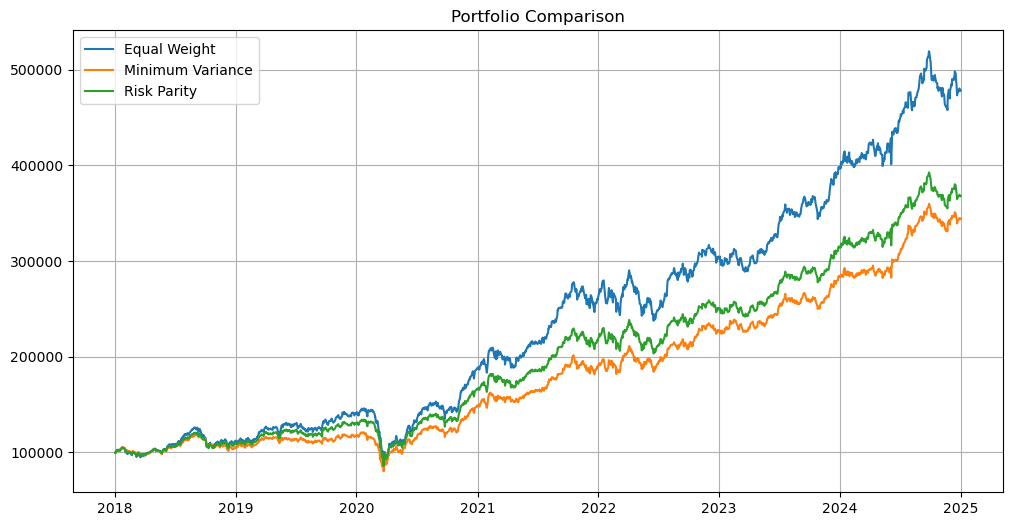

In [107]:
plt.figure(figsize=(12,6))

plt.plot(
    portfolio_nav,
    label="Equal Weight"
)

plt.plot(
    min_var_nav,
    label="Minimum Variance"
)

plt.plot(
    risk_parity_nav,
    label="Risk Parity"
)

plt.title(
    "Portfolio Comparison"
)

plt.legend()

plt.grid(True)

plt.show()

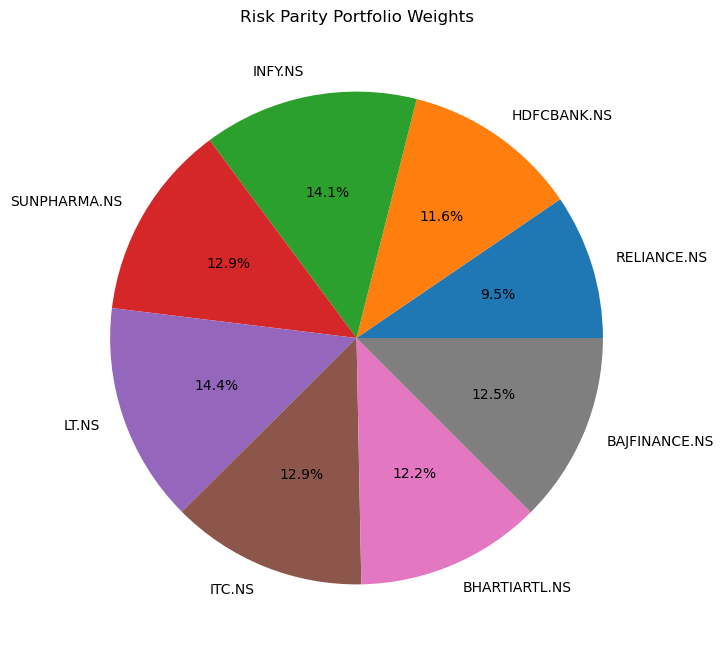

In [108]:
plt.figure(figsize=(8,8))

plt.pie(
    risk_parity_weights,
    labels=stocks,
    autopct='%1.1f%%'
)

plt.title(
    "Risk Parity Portfolio Weights"
)

plt.show()

In [109]:
def portfolio_metrics(
    returns_series,
    nav_series
):

    years = len(
        returns_series
    ) / 252

    cagr = (
        nav_series.iloc[-1]
        /
        nav_series.iloc[0]
    ) ** (1/years) - 1

    vol = (
        returns_series.std()
        *
        np.sqrt(252)
    )

    sharpe = (
        returns_series.mean()*252
    ) / vol

    running_max = (
        nav_series.cummax()
    )

    drawdown = (
        nav_series
        -
        running_max
    ) / running_max

    max_dd = drawdown.min()

    return [
        round(cagr*100,2),
        round(vol*100,2),
        round(sharpe,2),
        round(max_dd*100,2)
    ]

In [110]:
comparison = pd.DataFrame({

    "Portfolio":[
        "Equal Weight",
        "Minimum Variance",
        "Risk Parity"
    ],

    "CAGR":[
        portfolio_metrics(
            portfolio_returns,
            portfolio_nav
        )[0],

        portfolio_metrics(
            min_var_returns,
            min_var_nav
        )[0],

        portfolio_metrics(
            risk_parity_returns,
            risk_parity_nav
        )[0]
    ],

    "Volatility":[
        portfolio_metrics(
            portfolio_returns,
            portfolio_nav
        )[1],

        portfolio_metrics(
            min_var_returns,
            min_var_nav
        )[1],

        portfolio_metrics(
            risk_parity_returns,
            risk_parity_nav
        )[1]
    ],

    "Sharpe":[
        portfolio_metrics(
            portfolio_returns,
            portfolio_nav
        )[2],

        portfolio_metrics(
            min_var_returns,
            min_var_nav
        )[2],

        portfolio_metrics(
            risk_parity_returns,
            risk_parity_nav
        )[2]
    ],

    "Max Drawdown":[
        portfolio_metrics(
            portfolio_returns,
            portfolio_nav
        )[3],

        portfolio_metrics(
            min_var_returns,
            min_var_nav
        )[3],

        portfolio_metrics(
            risk_parity_returns,
            risk_parity_nav
        )[3]
    ]
})

comparison

,Portfolio,CAGR,Volatility,Sharpe,Max Drawdown
0,Equal Weight,25.75,21.53,1.17,-42.01
1,Minimum Variance,19.83,16.65,1.17,-33.66
2,Risk Parity,21.02,17.60,1.17,-36.01



Maximum Sharpe Portfolio

RELIANCE.NS: 13.34%
HDFCBANK.NS: 17.39%
INFY.NS: 0.52%
SUNPHARMA.NS: 30.84%
LT.NS: 11.03%
ITC.NS: 1.04%
BHARTIARTL.NS: 0.43%
BAJFINANCE.NS: 25.41%

Expected Return: 23.21 %
Volatility: 18.51 %
Sharpe: 0.93


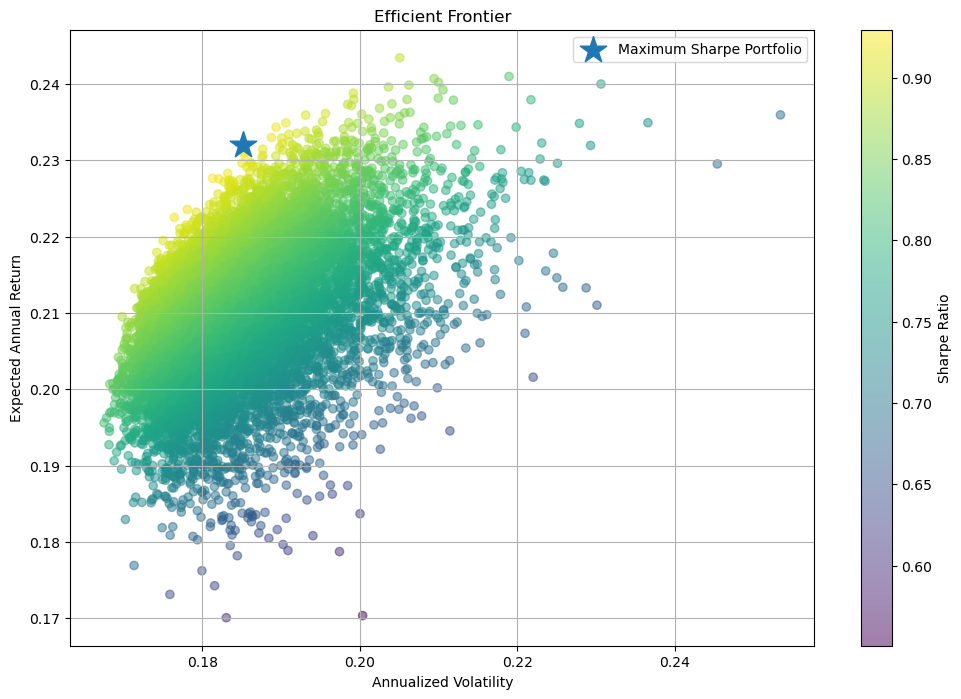


Maximum Sharpe Weights

           Stock  Weight
0    RELIANCE.NS   13.34
1    HDFCBANK.NS   17.39
2        INFY.NS    0.52
3   SUNPHARMA.NS   30.84
4          LT.NS   11.03
5         ITC.NS    1.04
6  BHARTIARTL.NS    0.43
7  BAJFINANCE.NS   25.41


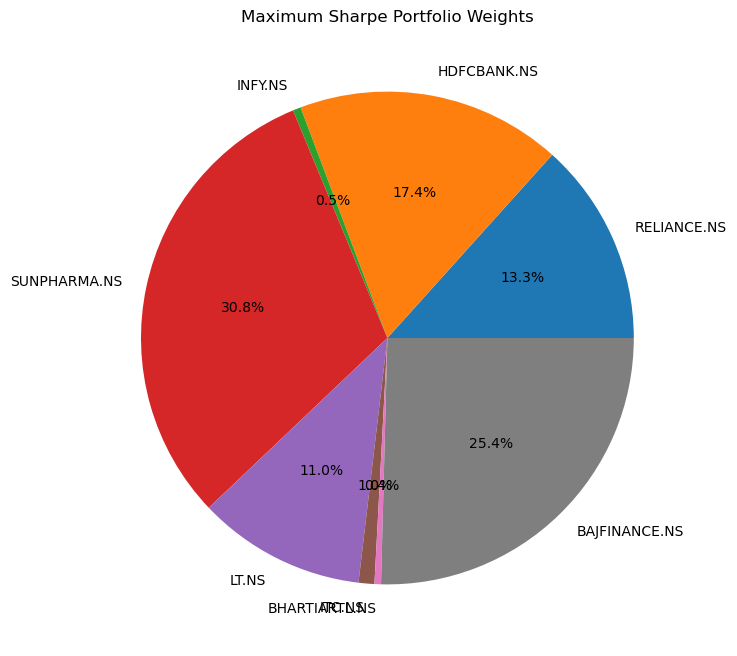

In [111]:
annual_returns = returns.mean() * 252
annual_cov = returns.cov() * 252

num_assets = len(stocks)

num_portfolios = 10000

results = np.zeros((4, num_portfolios))

weights_record = []

risk_free_rate = 0.06

for i in range(num_portfolios):

    weights = np.random.random(num_assets)

    weights /= np.sum(weights)

    weights_record.append(weights)

    portfolio_return = np.sum(
        annual_returns * weights
    )

    portfolio_volatility = np.sqrt(
        np.dot(
            weights.T,
            np.dot(
                annual_cov,
                weights
            )
        )
    )

    sharpe_ratio = (
        portfolio_return
        - risk_free_rate
    ) / portfolio_volatility

    results[0, i] = portfolio_return
    results[1, i] = portfolio_volatility
    results[2, i] = sharpe_ratio
    results[3, i] = i

results = pd.DataFrame(results.T)

results.columns = [
    "Return",
    "Volatility",
    "Sharpe",
    "Index"
]

# ------------------------------------------------------------

max_sharpe_idx = results["Sharpe"].idxmax()

max_sharpe_portfolio = results.iloc[
    max_sharpe_idx
]

max_sharpe_weights = weights_record[
    int(max_sharpe_portfolio["Index"])
]

# ------------------------------------------------------------

print("\nMaximum Sharpe Portfolio\n")

for stock, weight in zip(
    stocks,
    max_sharpe_weights
):

    print(
        f"{stock}: {weight:.2%}"
    )

print()

print(
    "Expected Return:",
    round(
        max_sharpe_portfolio["Return"]*100,
        2
    ),
    "%"
)

print(
    "Volatility:",
    round(
        max_sharpe_portfolio["Volatility"]*100,
        2
    ),
    "%"
)

print(
    "Sharpe:",
    round(
        max_sharpe_portfolio["Sharpe"],
        2
    )
)

# ------------------------------------------------------------

plt.figure(figsize=(12,8))

scatter = plt.scatter(
    results["Volatility"],
    results["Return"],
    c=results["Sharpe"],
    cmap="viridis",
    alpha=0.5
)

plt.colorbar(
    scatter,
    label="Sharpe Ratio"
)

plt.scatter(
    max_sharpe_portfolio["Volatility"],
    max_sharpe_portfolio["Return"],
    marker="*",
    s=400,
    label="Maximum Sharpe Portfolio"
)

plt.xlabel(
    "Annualized Volatility"
)

plt.ylabel(
    "Expected Annual Return"
)

plt.title(
    "Efficient Frontier"
)

plt.legend()

plt.grid(True)

plt.savefig(
    "figures/efficient_frontier.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ------------------------------------------------------------

weights_df = pd.DataFrame({

    "Stock": stocks,

    "Weight":
    np.round(
        max_sharpe_weights * 100,
        2
    )

})

print("\nMaximum Sharpe Weights\n")

print(weights_df)

# ------------------------------------------------------------

plt.figure(figsize=(8,8))

plt.pie(
    max_sharpe_weights,
    labels=stocks,
    autopct="%1.1f%%"
)

plt.title(
    "Maximum Sharpe Portfolio Weights"
)

plt.savefig(
    "figures/max_sharpe_weights.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [112]:
weights_df

,Stock,Weight
0,RELIANCE.NS,13.34
1,HDFCBANK.NS,17.39
2,INFY.NS,0.52
3,SUNPHARMA.NS,30.84
4,LT.NS,11.03
5,ITC.NS,1.04
6,BHARTIARTL.NS,0.43
7,BAJFINANCE.NS,25.41


In [113]:
max_sharpe_portfolio

Return           0.232053
Volatility       0.185106
Sharpe           0.929481
Index         3454.000000
Name: 3454, dtype: float64

In [114]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.


C:\Users\bhara\AppData\Local\Temp\ipykernel_18932\2112109443.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample("M")


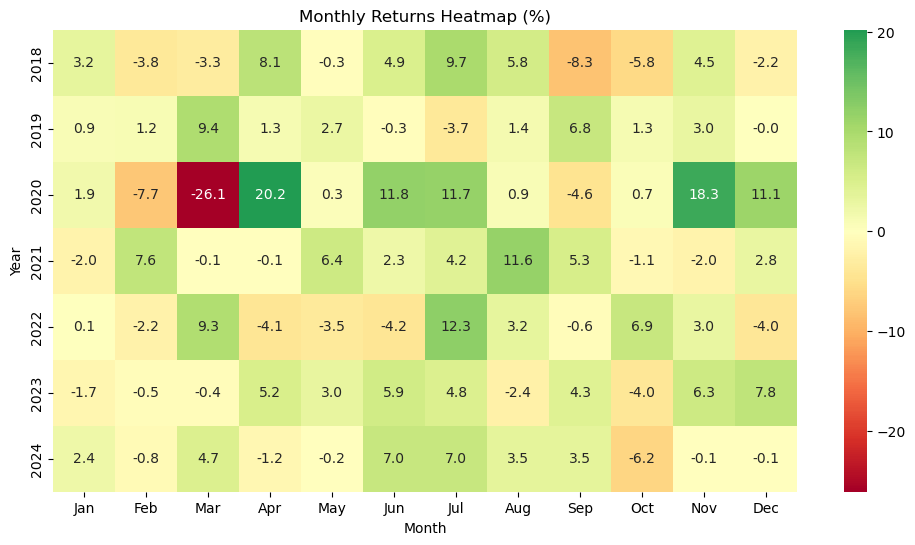

In [115]:
monthly_returns = (
    portfolio_returns
    .resample("M")
    .apply(
        lambda x:(1+x).prod()-1
    )
)

monthly_returns = monthly_returns.to_frame()

monthly_returns["Year"] = monthly_returns.index.year

monthly_returns["Month"] = monthly_returns.index.strftime("%b")

heatmap_data = monthly_returns.pivot(
    index="Year",
    columns="Month",
    values=0
)

month_order = [
    "Jan","Feb","Mar","Apr",
    "May","Jun","Jul","Aug",
    "Sep","Oct","Nov","Dec"
]

heatmap_data = heatmap_data.reindex(
    columns=month_order
)

import seaborn as sns

plt.figure(figsize=(12,6))

sns.heatmap(
    heatmap_data*100,
    annot=True,
    fmt=".1f",
    cmap="RdYlGn",
    center=0
)

plt.title(
    "Monthly Returns Heatmap (%)"
)

plt.savefig(
    "figures/monthly_returns_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

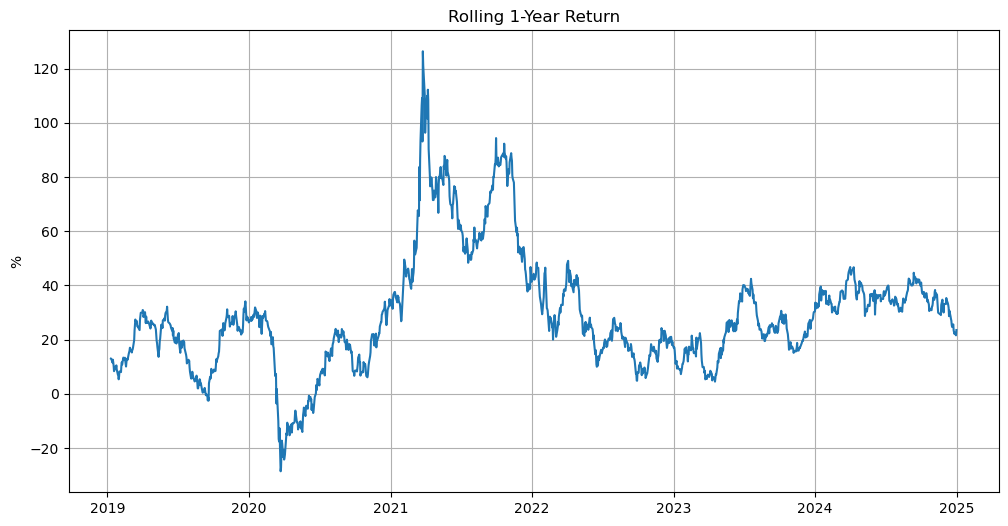

In [116]:
rolling_cagr = []

window = 252

for i in range(window,len(portfolio_nav)):

    start = portfolio_nav.iloc[
        i-window
    ]

    end = portfolio_nav.iloc[i]

    cagr_val = (
        end/start
    ) - 1

    rolling_cagr.append(
        cagr_val
    )

rolling_cagr = pd.Series(
    rolling_cagr,
    index=portfolio_nav.index[
        window:
    ]
)

plt.figure(figsize=(12,6))

plt.plot(
    rolling_cagr*100
)

plt.title(
    "Rolling 1-Year Return"
)

plt.ylabel("%")

plt.grid(True)

plt.savefig(
    "figures/rolling_cagr.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [117]:
sector_weights = pd.DataFrame({

    "Sector":[
        "Energy",
        "Banking",
        "IT",
        "Pharma",
        "Industrial",
        "FMCG",
        "Telecom",
        "NBFC"
    ],

    "Weight":[
        12.5,
        25,
        12.5,
        12.5,
        12.5,
        12.5,
        12.5,
        12.5
    ]

})

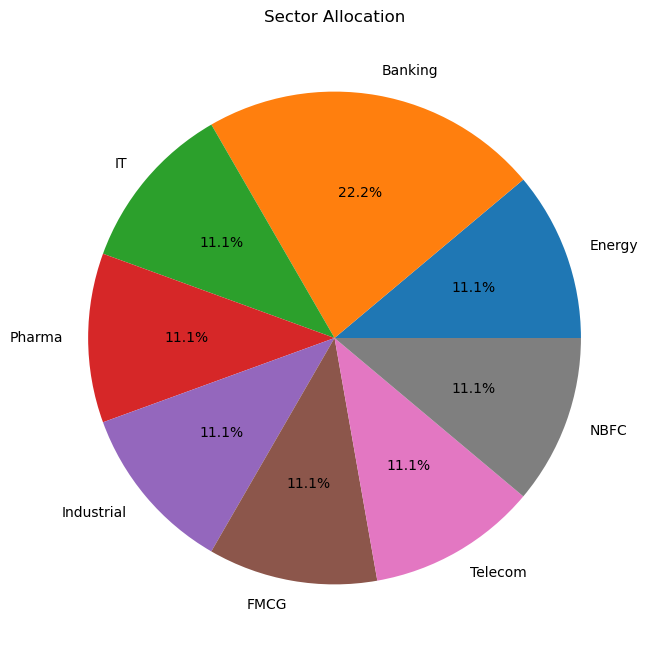

In [118]:
plt.figure(figsize=(8,8))

plt.pie(
    sector_weights["Weight"],
    labels=sector_weights["Sector"],
    autopct="%1.1f%%"
)

plt.title(
    "Sector Allocation"
)

plt.savefig(
    "figures/sector_allocation.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [119]:
portfolio_nav.to_csv(
    "outputs/dashboard_data/portfolio_nav.csv"
)

In [120]:
drawdown.to_csv(
    "outputs/dashboard_data/drawdown.csv"
)

rolling_vol.to_csv(
    "outputs/dashboard_data/rolling_volatility.csv"
)

rolling_sharpe.to_csv(
    "outputs/dashboard_data/rolling_sharpe.csv"
)

portfolio_returns.to_csv(
    "outputs/dashboard_data/portfolio_returns.csv"
)

metrics.to_csv(
    "outputs/dashboard_data/performance_metrics.csv",
    index=False
)

comparison.to_csv(
    "outputs/dashboard_data/portfolio_comparison.csv",
    index=False
)

regime_df.to_csv(
    "outputs/dashboard_data/hmm_regimes.csv"
)